<a href="https://colab.research.google.com/github/SemniCode/Company-Bankruptcy-Prediction/blob/main/Company_Bankruptcy_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from plotly.offline import iplot , plot
from plotly.subplots import make_subplots

In [ ]:
from google.colab import drive
drive.mount('/content/gdrive/')

file_path = "/content/gdrive/My Drive/Colab Notebooks/기계론/기말프로젝트/"

Drive already mounted at /content/gdrive/; to attempt to forcibly remount, call drive.mount("/content/gdrive/", force_remount=True).


In [ ]:
bkdata = pd.read_csv(file_path + 'data.csv')

In [ ]:
bkdata

,Bankrupt?,ROA(C) before interest and depreciation before interest,ROA(A) before interest and % after tax,ROA(B) before interest and depreciation after tax,Operating Gross Margin,Realized Sales Gross Margin,Operating Profit Rate,Pre-tax net Interest Rate,After-tax net Interest Rate,Non-industry income and expenditure/revenue,...,Net Income to Total Assets,Total assets to GNP price,No-credit Interval,Gross Profit to Sales,Net Income to Stockholder's Equity,Liability to Equity,Degree of Financial Leverage (DFL),Interest Coverage Ratio (Interest expense to EBIT),Net Income Flag,Equity to Liability
0,1,0.370594,0.424389,0.405750,0.601457,0.601457,0.998969,0.796887,0.808809,0.302646,...,0.716845,0.009219,0.622879,0.601453,0.827890,0.290202,0.026601,0.564050,1,0.016469
1,1,0.464291,0.538214,0.516730,0.610235,0.610235,0.998946,0.797380,0.809301,0.303556,...,0.795297,0.008323,0.623652,0.610237,0.839969,0.283846,0.264577,0.570175,1,0.020794
2,1,0.426071,0.499019,0.472295,0.601450,0.601364,0.998857,0.796403,0.808388,0.302035,...,0.774670,0.040003,0.623841,0.601449,0.836774,0.290189,0.026555,0.563706,1,0.016474
3,1,0.399844,0.451265,0.457733,0.583541,0.583541,0.998700,0.796967,0.808966,0.303350,...,0.739555,0.003252,0.622929,0.583538,0.834697,0.281721,0.026697,0.564663,1,0.023982
4,1,0.465022,0.538432,0.522298,0.598783,0.598783,0.998973,0.797366,0.809304,0.303475,...,0.795016,0.003878,0.623521,0.598782,0.839973,0.278514,0.024752,0.575617,1,0.035490
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6814,0,0.493687,0.539468,0.543230,0.604455,0.604462,0.998992,0.797409,0.809331,0.303510,...,0.799927,0.000466,0.623620,0.604455,0.840359,0.279606,0.027064,0.566193,1,0.029890
6815,0,0.475162,0.538269,0.524172,0.598308,0.598308,0.998992,0.797414,0.809327,0.303520,...,0.799748,0.001959,0.623931,0.598306,0.840306,0.278132,0.027009,0.566018,1,0.038284
6816,0,0.472725,0.533744,0.520638,0.610444,0.610213,0.998984,0.797401,0.809317,0.303512,...,0.797778,0.002840,0.624156,0.610441,0.840138,0.275789,0.026791,0.565158,1,0.097649
6817,0,0.506264,0.559911,0.554045,0.607850,0.607850,0.999074,0.797500,0.809399,0.303498,...,0.811808,0.002837,0.623957,0.607846,0.841084,0.277547,0.026822,0.565302,1,0.044009


In [ ]:
bkdata.shape

(6819, 96)

In [ ]:
bkdata.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6819 entries, 0 to 6818
Data columns (total 96 columns):
 #   Column                                                    Non-Null Count  Dtype  
---  ------                                                    --------------  -----  
 0   Bankrupt?                                                 6819 non-null   int64  
 1    ROA(C) before interest and depreciation before interest  6819 non-null   float64
 2    ROA(A) before interest and % after tax                   6819 non-null   float64
 3    ROA(B) before interest and depreciation after tax        6819 non-null   float64
 4    Operating Gross Margin                                   6819 non-null   float64
 5    Realized Sales Gross Margin                              6819 non-null   float64
 6    Operating Profit Rate                                    6819 non-null   float64
 7    Pre-tax net Interest Rate                                6819 non-null   float64
 8    After-tax net Int

In [ ]:
bkdata.columns

Index(['Bankrupt?', ' ROA(C) before interest and depreciation before interest',
       ' ROA(A) before interest and % after tax',
       ' ROA(B) before interest and depreciation after tax',
       ' Operating Gross Margin', ' Realized Sales Gross Margin',
       ' Operating Profit Rate', ' Pre-tax net Interest Rate',
       ' After-tax net Interest Rate',
       ' Non-industry income and expenditure/revenue',
       ' Continuous interest rate (after tax)', ' Operating Expense Rate',
       ' Research and development expense rate', ' Cash flow rate',
       ' Interest-bearing debt interest rate', ' Tax rate (A)',
       ' Net Value Per Share (B)', ' Net Value Per Share (A)',
       ' Net Value Per Share (C)', ' Persistent EPS in the Last Four Seasons',
       ' Cash Flow Per Share', ' Revenue Per Share (Yuan ¥)',
       ' Operating Profit Per Share (Yuan ¥)',
       ' Per Share Net profit before tax (Yuan ¥)',
       ' Realized Sales Gross Profit Growth Rate',
       ' Operating Profit

In [ ]:
bkdata.describe()

,Bankrupt?,ROA(C) before interest and depreciation before interest,ROA(A) before interest and % after tax,ROA(B) before interest and depreciation after tax,Operating Gross Margin,Realized Sales Gross Margin,Operating Profit Rate,Pre-tax net Interest Rate,After-tax net Interest Rate,Non-industry income and expenditure/revenue,...,Net Income to Total Assets,Total assets to GNP price,No-credit Interval,Gross Profit to Sales,Net Income to Stockholder's Equity,Liability to Equity,Degree of Financial Leverage (DFL),Interest Coverage Ratio (Interest expense to EBIT),Net Income Flag,Equity to Liability
count,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,...,6819.000000,6.819000e+03,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.0,6819.000000
mean,0.032263,0.505180,0.558625,0.553589,0.607948,0.607929,0.998755,0.797190,0.809084,0.303623,...,0.807760,1.862942e+07,0.623915,0.607946,0.840402,0.280365,0.027541,0.565358,1.0,0.047578
std,0.176710,0.060686,0.065620,0.061595,0.016934,0.016916,0.013010,0.012869,0.013601,0.011163,...,0.040332,3.764501e+08,0.012290,0.016934,0.014523,0.014463,0.015668,0.013214,0.0,0.050014
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.0,0.000000
25%,0.000000,0.476527,0.535543,0.527277,0.600445,0.600434,0.998969,0.797386,0.809312,0.303466,...,0.796750,9.036205e-04,0.623636,0.600443,0.840115,0.276944,0.026791,0.565158,1.0,0.024477
50%,0.000000,0.502706,0.559802,0.552278,0.605997,0.605976,0.999022,0.797464,0.809375,0.303525,...,0.810619,2.085213e-03,0.623879,0.605998,0.841179,0.278778,0.026808,0.565252,1.0,0.033798
75%,0.000000,0.535563,0.589157,0.584105,0.613914,0.613842,0.999095,0.797579,0.809469,0.303585,...,0.826455,5.269777e-03,0.624168,0.613913,0.842357,0.281449,0.026913,0.565725,1.0,0.052838
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,9.820000e+09,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.0,1.000000


In [ ]:
bkdata.sample(5)

,Bankrupt?,ROA(C) before interest and depreciation before interest,ROA(A) before interest and % after tax,ROA(B) before interest and depreciation after tax,Operating Gross Margin,Realized Sales Gross Margin,Operating Profit Rate,Pre-tax net Interest Rate,After-tax net Interest Rate,Non-industry income and expenditure/revenue,...,Net Income to Total Assets,Total assets to GNP price,No-credit Interval,Gross Profit to Sales,Net Income to Stockholder's Equity,Liability to Equity,Degree of Financial Leverage (DFL),Interest Coverage Ratio (Interest expense to EBIT),Net Income Flag,Equity to Liability
2432,0,0.491396,0.561055,0.543552,0.614271,0.614271,0.999222,0.797680,0.809569,0.303503,...,0.809982,0.006890,0.618327,0.614268,0.841827,0.286413,0.026877,0.565538,1,0.018483
6223,0,0.554575,0.616877,0.599229,0.602279,0.602279,0.999042,0.797517,0.809416,0.303595,...,0.837213,0.000807,0.624466,0.602278,0.842685,0.277303,0.026827,0.565324,1,0.047157
741,0,0.528640,0.586404,0.575941,0.604030,0.604239,0.999036,0.797500,0.809399,0.303577,...,0.824729,0.003996,0.623721,0.604027,0.842668,0.281224,0.026870,0.565507,1,0.025028
2978,0,0.498659,0.562364,0.546978,0.603670,0.603670,0.998904,0.797584,0.809459,0.304000,...,0.811988,0.004256,0.623674,0.603669,0.841105,0.277628,0.026897,0.565618,1,0.043080
686,0,0.499781,0.554187,0.551261,0.605666,0.605666,0.999038,0.797416,0.809327,0.303428,...,0.799842,0.000517,0.623539,0.605662,0.840516,0.285671,0.028833,0.568479,1,0.019040


In [ ]:
bkdata.isna().sum()

,0
Bankrupt?,0
ROA(C) before interest and depreciation before interest,0
ROA(A) before interest and % after tax,0
ROA(B) before interest and depreciation after tax,0
Operating Gross Margin,0
...,...
Liability to Equity,0
Degree of Financial Leverage (DFL),0
Interest Coverage Ratio (Interest expense to EBIT),0
Net Income Flag,0


In [ ]:
bkdata.isna().any()

,0
Bankrupt?,False
ROA(C) before interest and depreciation before interest,False
ROA(A) before interest and % after tax,False
ROA(B) before interest and depreciation after tax,False
Operating Gross Margin,False
...,...
Liability to Equity,False
Degree of Financial Leverage (DFL),False
Interest Coverage Ratio (Interest expense to EBIT),False
Net Income Flag,False


In [ ]:
bkdata.duplicated().any()

False

In [ ]:
bkdata['Bankrupt?'].unique()

array([1, 0])

In [ ]:
bkdata['Bankrupt?'].value_counts()

,count
Bankrupt?,
0,6599
1,220


Data visualization

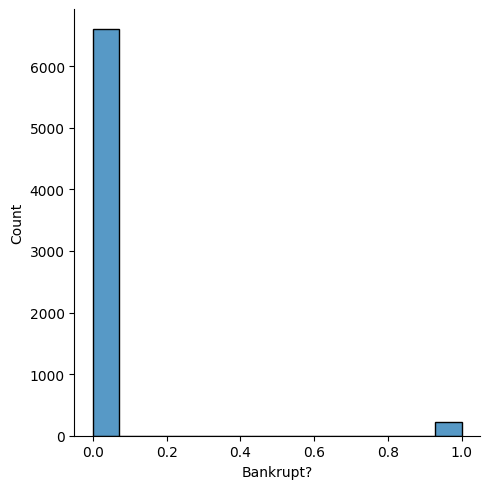

In [ ]:
#filtered_data = bkdata[bkdata['Bankrupt?'].isin([0, 1])]

# Plot the distribution
#sns.displot(filtered_data['Bankrupt?'], bins=2, discrete=True)
sns.displot(bkdata['Bankrupt?'])

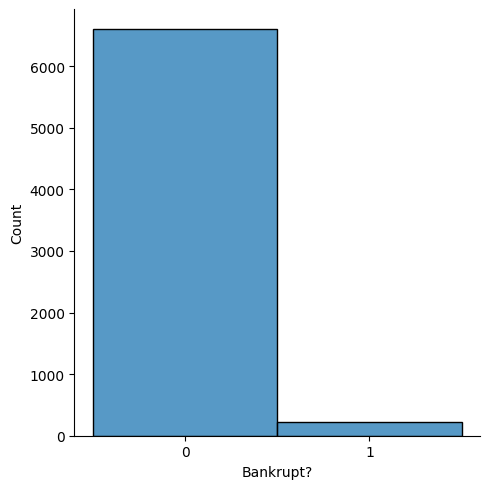

In [ ]:
sns.displot(bkdata['Bankrupt?'], bins=[-0.5, 0.5, 1.5], discrete=True)

# Adjust the x-axis to show only 0 and 1
plt.xticks([0, 1])
plt.show()

Data preprocessing

In [ ]:
x=bkdata.drop('Bankrupt?',axis=1)
y=bkdata['Bankrupt?']

In [ ]:
from sklearn.preprocessing import LabelEncoder
encoder_x=LabelEncoder()

In [ ]:
for col in x.columns:
    x[col]=encoder_x.fit_transform(x[col])

In [ ]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=.3,shuffle=True,random_state=42)

In [ ]:
print("x_train shape = ", x_train.shape)
print("y_train shape = ", y_train.shape)
print("x_test shape = ", x_test.shape)
print("y_test shape = ", y_test.shape)

x_train shape =  (4773, 95)
y_train shape =  (4773,)
x_test shape =  (2046, 95)
y_test shape =  (2046,)


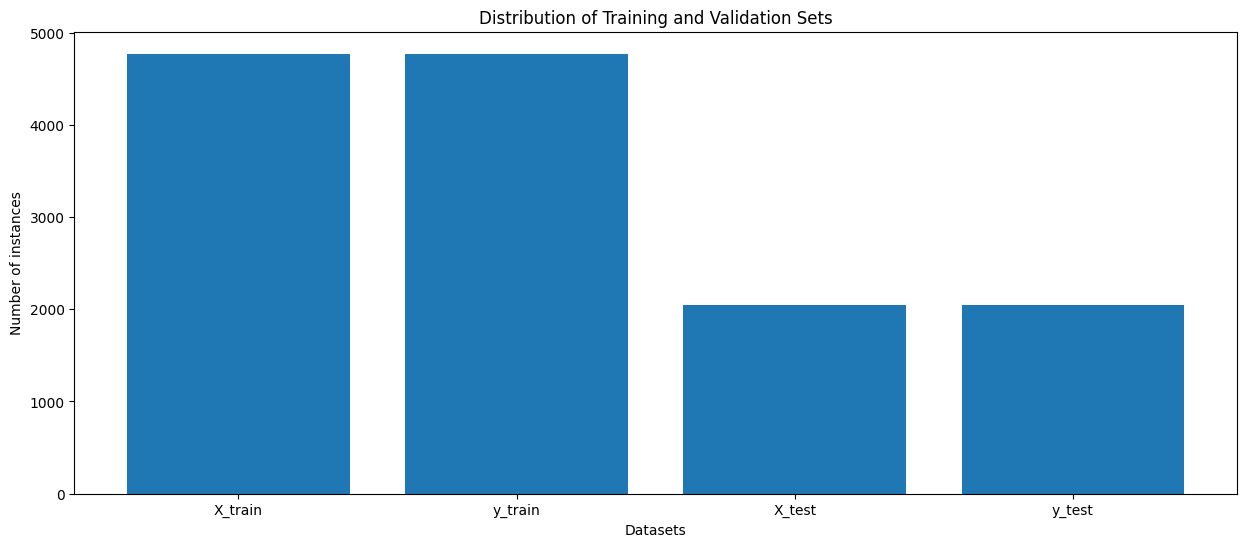

In [ ]:
shapes = {
    'X_train': x_train.shape[0],
    'y_train': y_train.shape[0],
    'X_test': x_test.shape[0],
    'y_test': y_test.shape[0]
}
plt.figure(figsize=(15, 6))
plt.bar(shapes.keys(), shapes.values())
plt.xlabel('Datasets')
plt.ylabel('Number of instances')
plt.title('Distribution of Training and Validation Sets')
plt.show()

Scaling Data

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
x_train=scaler.fit_transform(x_train)
x_test=scaler.fit_transform(x_test)

Logistic Regression Model

In [ ]:
from sklearn.linear_model import LogisticRegression
lr_model=LogisticRegression() # call model
lr_model.fit(x_train,y_train)

LogisticRegression()

In [ ]:
y_pred=lr_model.predict(x_test)
y_pred

array([0, 0, 0, ..., 0, 0, 0])

<Axes: >

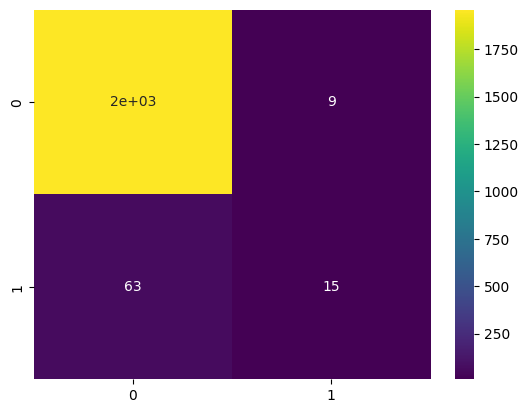

In [ ]:
from sklearn.metrics import confusion_matrix
con= confusion_matrix(y_test,y_pred) # Evaluation of Model Performance & Sensitivity and Specificity Analysis
sns.heatmap(con, annot=True, cmap='viridis', cbar=True) # heatmap for Matrix Data Representation

In [ ]:
from sklearn.metrics import classification_report # for Precision and Recall Analysis
print("classification_report is ",classification_report(y_test ,y_pred))

classification_report is                precision    recall  f1-score   support

           0       0.97      1.00      0.98      1968
           1       0.62      0.19      0.29        78

    accuracy                           0.96      2046
   macro avg       0.80      0.59      0.64      2046
weighted avg       0.96      0.96      0.96      2046



In [ ]:
y_prob = lr_model.predict_proba(x_test)
print(y_prob)

[[9.99116289e-01 8.83710948e-04]
 [9.99305350e-01 6.94649749e-04]
 [9.99992382e-01 7.61837120e-06]
 ...
 [9.99845932e-01 1.54068029e-04]
 [9.99955803e-01 4.41968894e-05]
 [9.99132305e-01 8.67695231e-04]]


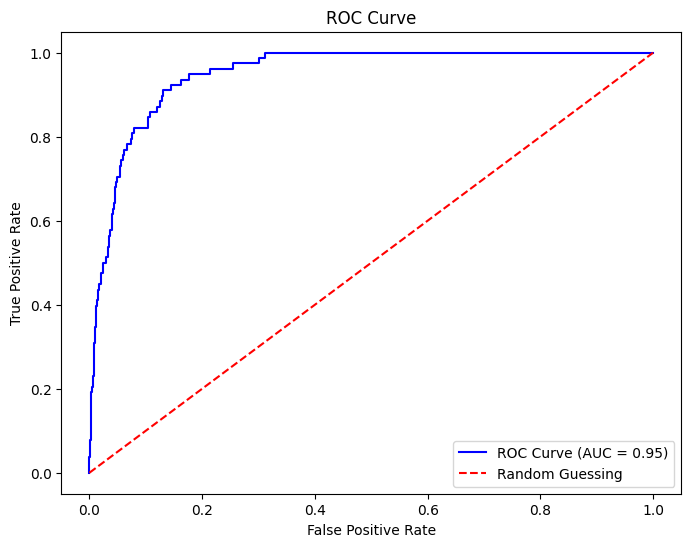

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Get predicted probabilities
y_prob = lr_model.predict_proba(x_test)[:, 1]  # 1 클래스에 대한 확률값

# Calculate FPR, TPR, and thresholds
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# Calculate AUC
roc_auc = auc(fpr, tpr)

# Plot ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='Random Guessing')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()


In [ ]:
# Logistic Regression 모델의 가중치와 특성 이름 추출
coefficients = lr_model.coef_[0]  # Logistic Regression 가중치
feature_names = [' ROA(C) before interest and depreciation before interest',
       ' ROA(A) before interest and % after tax',
       ' ROA(B) before interest and depreciation after tax',
       ' Operating Gross Margin', ' Realized Sales Gross Margin',
       ' Operating Profit Rate', ' Pre-tax net Interest Rate',
       ' After-tax net Interest Rate',
       ' Non-industry income and expenditure/revenue',
       ' Continuous interest rate (after tax)', ' Operating Expense Rate',
       ' Research and development expense rate', ' Cash flow rate',
       ' Interest-bearing debt interest rate', ' Tax rate (A)',
       ' Net Value Per Share (B)', ' Net Value Per Share (A)',
       ' Net Value Per Share (C)', ' Persistent EPS in the Last Four Seasons',
       ' Cash Flow Per Share', ' Revenue Per Share (Yuan ¥)',
       ' Operating Profit Per Share (Yuan ¥)',
       ' Per Share Net profit before tax (Yuan ¥)',
       ' Realized Sales Gross Profit Growth Rate',
       ' Operating Profit Growth Rate', ' After-tax Net Profit Growth Rate',
       ' Regular Net Profit Growth Rate', ' Continuous Net Profit Growth Rate',
       ' Total Asset Growth Rate', ' Net Value Growth Rate',
       ' Total Asset Return Growth Rate Ratio', ' Cash Reinvestment %',
       ' Current Ratio', ' Quick Ratio', ' Interest Expense Ratio',
       ' Total debt/Total net worth', ' Debt ratio %', ' Net worth/Assets',
       ' Long-term fund suitability ratio (A)', ' Borrowing dependency',
       ' Contingent liabilities/Net worth',
       ' Operating profit/Paid-in capital',
       ' Net profit before tax/Paid-in capital',
       ' Inventory and accounts receivable/Net value', ' Total Asset Turnover',
       ' Accounts Receivable Turnover', ' Average Collection Days',
       ' Inventory Turnover Rate (times)', ' Fixed Assets Turnover Frequency',
       ' Net Worth Turnover Rate (times)', ' Revenue per person',
       ' Operating profit per person', ' Allocation rate per person',
       ' Working Capital to Total Assets', ' Quick Assets/Total Assets',
       ' Current Assets/Total Assets', ' Cash/Total Assets',
       ' Quick Assets/Current Liability', ' Cash/Current Liability',
       ' Current Liability to Assets', ' Operating Funds to Liability',
       ' Inventory/Working Capital', ' Inventory/Current Liability',
       ' Current Liabilities/Liability', ' Working Capital/Equity',
       ' Current Liabilities/Equity', ' Long-term Liability to Current Assets',
       ' Retained Earnings to Total Assets', ' Total income/Total expense',
       ' Total expense/Assets', ' Current Asset Turnover Rate',
       ' Quick Asset Turnover Rate', ' Working capitcal Turnover Rate',
       ' Cash Turnover Rate', ' Cash Flow to Sales', ' Fixed Assets to Assets',
       ' Current Liability to Liability', ' Current Liability to Equity',
       ' Equity to Long-term Liability', ' Cash Flow to Total Assets',
       ' Cash Flow to Liability', ' CFO to Assets', ' Cash Flow to Equity',
       ' Current Liability to Current Assets', ' Liability-Assets Flag',
       ' Net Income to Total Assets', ' Total assets to GNP price',
       ' No-credit Interval', ' Gross Profit to Sales',
       ' Net Income to Stockholders Equity', ' Liability to Equity',
       ' Degree of Financial Leverage (DFL)',
       ' Interest Coverage Ratio (Interest expense to EBIT)',
       ' Net Income Flag', ' Equity to Liability']

# 가중치와 특성 이름으로 DataFrame 생성
feature_importance = pd.DataFrame({
    "Feature": feature_names,  # 특성 이름
    "Coefficient": coefficients  # 가중치 값
})

# 가중치의 절대값 기준으로 정렬
feature_importance['Absolute Coefficient'] = feature_importance['Coefficient'].abs()
feature_importance = feature_importance.sort_values(by='Absolute Coefficient', ascending=False)

# 결과 출력
print(feature_importance)


                                     Feature  Coefficient  \
35                Total debt/Total net worth     1.420470   
18   Persistent EPS in the Last Four Seasons    -1.021487   
33                               Quick Ratio    -0.929029   
88                     Gross Profit to Sales    -0.747993   
74                        Cash Flow to Sales    -0.647667   
..                                       ...          ...   
40          Contingent liabilities/Net worth    -0.011900   
1     ROA(A) before interest and % after tax    -0.007841   
5                      Operating Profit Rate    -0.004569   
79                 Cash Flow to Total Assets    -0.002201   
93                           Net Income Flag     0.000000   

    Absolute Coefficient  
35              1.420470  
18              1.021487  
33              0.929029  
88              0.747993  
74              0.647667  
..                   ...  
40              0.011900  
1               0.007841  
5               0.004569

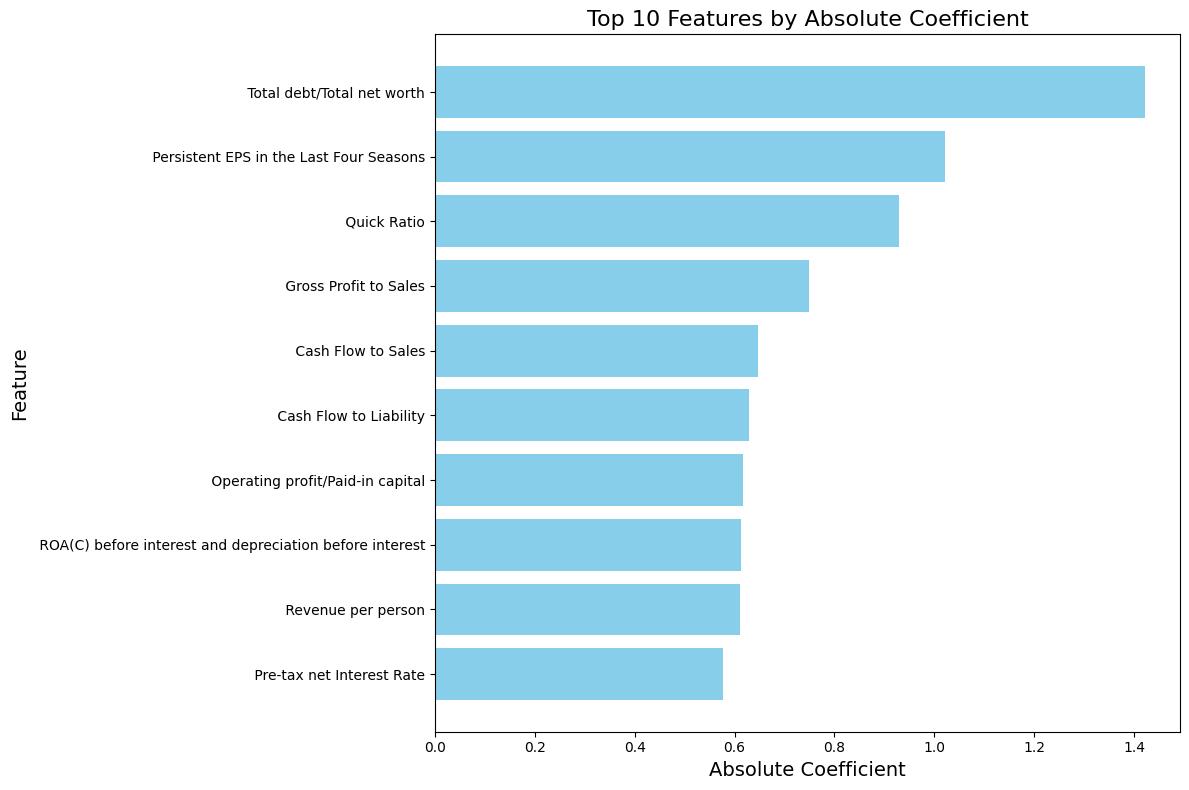

In [ ]:
# 상위 n개의 특성 선택 (예: 상위 10개)
top_n = 10
top_features = feature_importance.head(top_n)

# 막대 그래프 그리기
plt.figure(figsize=(12, 8))
plt.barh(top_features['Feature'], top_features['Absolute Coefficient'], color='skyblue')
plt.xlabel('Absolute Coefficient', fontsize=14)
plt.ylabel('Feature', fontsize=14)
plt.title(f'Top {top_n} Features by Absolute Coefficient', fontsize=16)
plt.gca().invert_yaxis()  # Y축 뒤집기 (큰 값이 위로 오게)
plt.tight_layout()
plt.show()

SVM

In [ ]:
from sklearn.svm import SVC
from sklearn.svm import SVC ## call model
svm_model =SVC()
svm_model.fit(x_train, y_train)

SVC()

In [ ]:
y_pred = svm_model.predict(x_test)
y_pred

array([0, 0, 0, ..., 0, 0, 0])

In [ ]:
print("classification_report is ",classification_report(y_test ,y_pred))

classification_report is                precision    recall  f1-score   support

           0       0.96      1.00      0.98      1968
           1       1.00      0.01      0.03        78

    accuracy                           0.96      2046
   macro avg       0.98      0.51      0.50      2046
weighted avg       0.96      0.96      0.94      2046



In [ ]:
from sklearn.calibration import CalibratedClassifierCV
from sklearn.svm import LinearSVC
base_svm = LinearSVC()
calibrated_svm = CalibratedClassifierCV(base_svm, cv=5)
calibrated_svm.fit(x_train, y_train)
y_prob = calibrated_svm.predict_proba(x_test)
print(y_prob)

[[0.98977224 0.01022776]
 [0.98801739 0.01198261]
 [0.99899172 0.00100828]
 ...
 [0.99507033 0.00492967]
 [0.99735445 0.00264555]
 [0.99293199 0.00706801]]


In [ ]:
y_prob = svm_model.predict_proba(x_test)
print(y_prob)

AttributeError: This 'SVC' has no attribute 'predict_proba'

In [ ]:
# Reinitialize SVC with probability=True
svm_model = SVC(probability=True)

# Refit the model
svm_model.fit(x_train, y_train)

# Predict class probabilities
y_prob = svm_model.predict_proba(x_test)

# Output probabilities
print(y_prob)

[[0.98638041 0.01361959]
 [0.98422513 0.01577487]
 [0.99151841 0.00848159]
 ...
 [0.99455855 0.00544145]
 [0.98317232 0.01682768]
 [0.98334602 0.01665398]]


In [ ]:
coefficients = svm_model.coef_[0]
feature_names = [' ROA(C) before interest and depreciation before interest',
       ' ROA(A) before interest and % after tax',
       ' ROA(B) before interest and depreciation after tax',
       ' Operating Gross Margin', ' Realized Sales Gross Margin',
       ' Operating Profit Rate', ' Pre-tax net Interest Rate',
       ' After-tax net Interest Rate',
       ' Non-industry income and expenditure/revenue',
       ' Continuous interest rate (after tax)', ' Operating Expense Rate',
       ' Research and development expense rate', ' Cash flow rate',
       ' Interest-bearing debt interest rate', ' Tax rate (A)',
       ' Net Value Per Share (B)', ' Net Value Per Share (A)',
       ' Net Value Per Share (C)', ' Persistent EPS in the Last Four Seasons',
       ' Cash Flow Per Share', ' Revenue Per Share (Yuan ¥)',
       ' Operating Profit Per Share (Yuan ¥)',
       ' Per Share Net profit before tax (Yuan ¥)',
       ' Realized Sales Gross Profit Growth Rate',
       ' Operating Profit Growth Rate', ' After-tax Net Profit Growth Rate',
       ' Regular Net Profit Growth Rate', ' Continuous Net Profit Growth Rate',
       ' Total Asset Growth Rate', ' Net Value Growth Rate',
       ' Total Asset Return Growth Rate Ratio', ' Cash Reinvestment %',
       ' Current Ratio', ' Quick Ratio', ' Interest Expense Ratio',
       ' Total debt/Total net worth', ' Debt ratio %', ' Net worth/Assets',
       ' Long-term fund suitability ratio (A)', ' Borrowing dependency',
       ' Contingent liabilities/Net worth',
       ' Operating profit/Paid-in capital',
       ' Net profit before tax/Paid-in capital',
       ' Inventory and accounts receivable/Net value', ' Total Asset Turnover',
       ' Accounts Receivable Turnover', ' Average Collection Days',
       ' Inventory Turnover Rate (times)', ' Fixed Assets Turnover Frequency',
       ' Net Worth Turnover Rate (times)', ' Revenue per person',
       ' Operating profit per person', ' Allocation rate per person',
       ' Working Capital to Total Assets', ' Quick Assets/Total Assets',
       ' Current Assets/Total Assets', ' Cash/Total Assets',
       ' Quick Assets/Current Liability', ' Cash/Current Liability',
       ' Current Liability to Assets', ' Operating Funds to Liability',
       ' Inventory/Working Capital', ' Inventory/Current Liability',
       ' Current Liabilities/Liability', ' Working Capital/Equity',
       ' Current Liabilities/Equity', ' Long-term Liability to Current Assets',
       ' Retained Earnings to Total Assets', ' Total income/Total expense',
       ' Total expense/Assets', ' Current Asset Turnover Rate',
       ' Quick Asset Turnover Rate', ' Working capitcal Turnover Rate',
       ' Cash Turnover Rate', ' Cash Flow to Sales', ' Fixed Assets to Assets',
       ' Current Liability to Liability', ' Current Liability to Equity',
       ' Equity to Long-term Liability', ' Cash Flow to Total Assets',
       ' Cash Flow to Liability', ' CFO to Assets', ' Cash Flow to Equity',
       ' Current Liability to Current Assets', ' Liability-Assets Flag',
       ' Net Income to Total Assets', ' Total assets to GNP price',
       ' No-credit Interval', ' Gross Profit to Sales',
       ' Net Income to Stockholders Equity', ' Liability to Equity',
       ' Degree of Financial Leverage (DFL)',
       ' Interest Coverage Ratio (Interest expense to EBIT)',
       ' Net Income Flag', ' Equity to Liability']

# 가중치와 특성 이름으로 DataFrame 생성
feature_importance = pd.DataFrame({
    "Feature": feature_names,  # 특성 이름
    "Coefficient": coefficients  # 가중치 값
})

# 가중치의 절대값 기준으로 정렬
feature_importance['Absolute Coefficient'] = feature_importance['Coefficient'].abs()
feature_importance = feature_importance.sort_values(by='Absolute Coefficient', ascending=False)

# 결과 출력
print(feature_importance)

AttributeError: coef_ is only available when using a linear kernel

In [ ]:
from sklearn.svm import SVC
import pandas as pd

# Linear Kernel SVM
svm_model = SVC(kernel='linear', probability=True)
svm_model.fit(x_train, y_train)

# Coefficients and feature names
coefficients = svm_model.coef_[0]  # Extract coefficients for linear SVM
feature_names = [...]  # Replace with your feature names

# Create DataFrame for feature importance
feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

# Sort by absolute coefficient value
feature_importance['Absolute Coefficient'] = feature_importance['Coefficient'].abs()
feature_importance = feature_importance.sort_values(by='Absolute Coefficient', ascending=False)

# Display results
print(feature_importance)


ValueError: All arrays must be of the same length

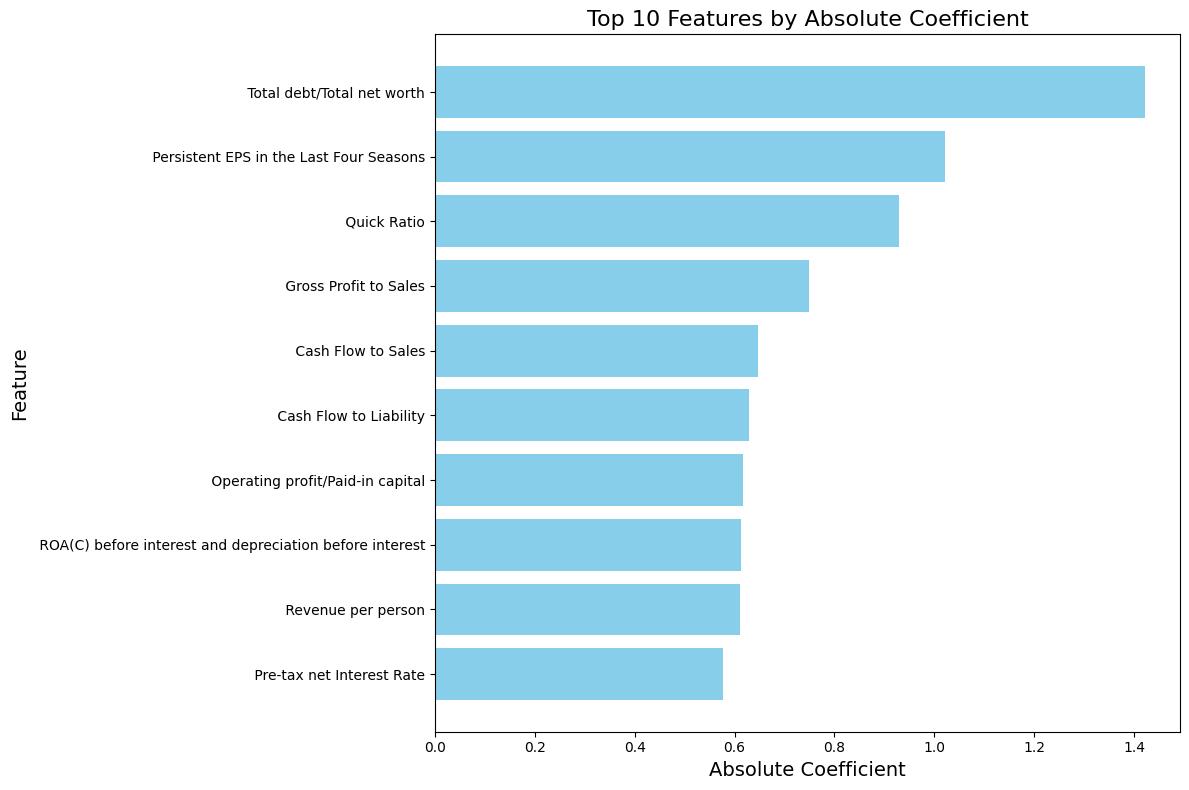

In [ ]:
# 상위 n개의 특성 선택 (예: 상위 10개)
top_n = 10
top_features = feature_importance.head(top_n)

# 막대 그래프 그리기
plt.figure(figsize=(12, 8))
plt.barh(top_features['Feature'], top_features['Absolute Coefficient'], color='skyblue')
plt.xlabel('Absolute Coefficient', fontsize=14)
plt.ylabel('Feature', fontsize=14)
plt.title(f'Top {top_n} Features by Absolute Coefficient', fontsize=16)
plt.gca().invert_yaxis()  # Y축 뒤집기 (큰 값이 위로 오게)
plt.tight_layout()
plt.show()

In [ ]:
import pickle
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
from imblearn.over_sampling import RandomOverSampler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import ConfusionMatrixDisplay , classification_report ,f1_score
from sklearn.model_selection import train_test_split , GridSearchCV
from sklearn.pipeline import make_pipeline

In [ ]:
df = pd.read_csv(file_path + "data.csv")
df.head()

,Bankrupt?,ROA(C) before interest and depreciation before interest,ROA(A) before interest and % after tax,ROA(B) before interest and depreciation after tax,Operating Gross Margin,Realized Sales Gross Margin,Operating Profit Rate,Pre-tax net Interest Rate,After-tax net Interest Rate,Non-industry income and expenditure/revenue,...,Net Income to Total Assets,Total assets to GNP price,No-credit Interval,Gross Profit to Sales,Net Income to Stockholder's Equity,Liability to Equity,Degree of Financial Leverage (DFL),Interest Coverage Ratio (Interest expense to EBIT),Net Income Flag,Equity to Liability
0,1,0.370594,0.424389,0.405750,0.601457,0.601457,0.998969,0.796887,0.808809,0.302646,...,0.716845,0.009219,0.622879,0.601453,0.827890,0.290202,0.026601,0.564050,1,0.016469
1,1,0.464291,0.538214,0.516730,0.610235,0.610235,0.998946,0.797380,0.809301,0.303556,...,0.795297,0.008323,0.623652,0.610237,0.839969,0.283846,0.264577,0.570175,1,0.020794
2,1,0.426071,0.499019,0.472295,0.601450,0.601364,0.998857,0.796403,0.808388,0.302035,...,0.774670,0.040003,0.623841,0.601449,0.836774,0.290189,0.026555,0.563706,1,0.016474
3,1,0.399844,0.451265,0.457733,0.583541,0.583541,0.998700,0.796967,0.808966,0.303350,...,0.739555,0.003252,0.622929,0.583538,0.834697,0.281721,0.026697,0.564663,1,0.023982
4,1,0.465022,0.538432,0.522298,0.598783,0.598783,0.998973,0.797366,0.809304,0.303475,...,0.795016,0.003878,0.623521,0.598782,0.839973,0.278514,0.024752,0.575617,1,0.035490


Text(0.5, 1.0, 'Class balance')

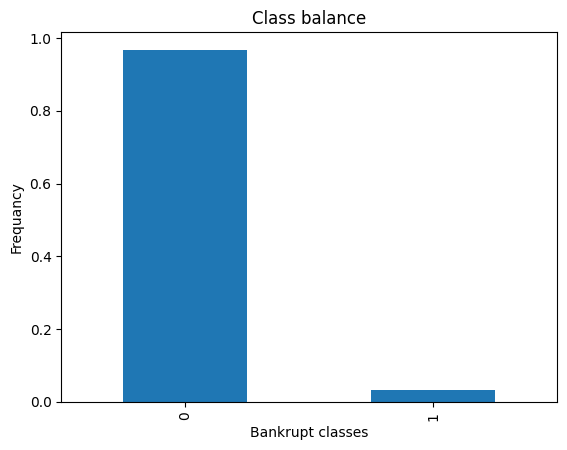

In [ ]:
df['Bankrupt?'].value_counts(normalize= True).plot(kind= 'bar')
plt.xlabel("Bankrupt classes")
plt.ylabel("Frequancy")
plt.title("Class balance")

the distributions of the "_Net_Income_to_Total_Assets" column for both groups in the "bankrupt" column

<ipython-input-60-08dba7e555f6>:1: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




Text(0.5, 1.0, 'Distribution of Profit/ Net Income Ratio, by Class')

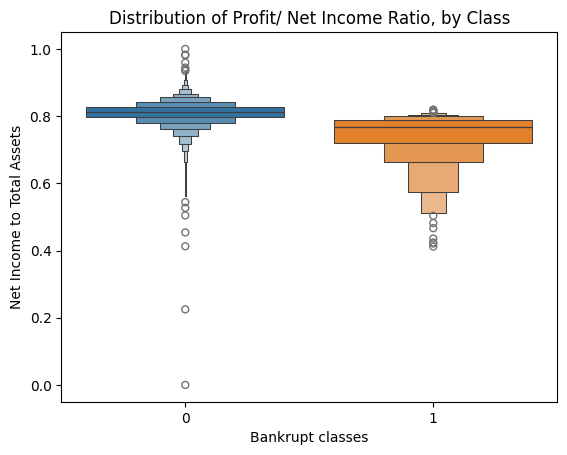

In [ ]:
sns.boxenplot(x="Bankrupt?" , y=" Net Income to Total Assets" , data=df, palette=["#1f77b4", "#ff7f0e"])
plt.xlabel("Bankrupt classes")
plt.ylabel("Net Income to Total Assets")
plt.title("Distribution of Profit/ Net Income Ratio, by Class")

In [ ]:
df[' Net Income to Total Assets'].describe()

,Net Income to Total Assets
count,6819.000000
mean,0.807760
std,0.040332
min,0.000000
25%,0.796750
50%,0.810619
75%,0.826455
max,1.000000


create a histogram to check whether the distrbution is skewed significantly or not

Text(0.5, 1.0, 'Distrbution of Net Income to Total Assets Ratio')

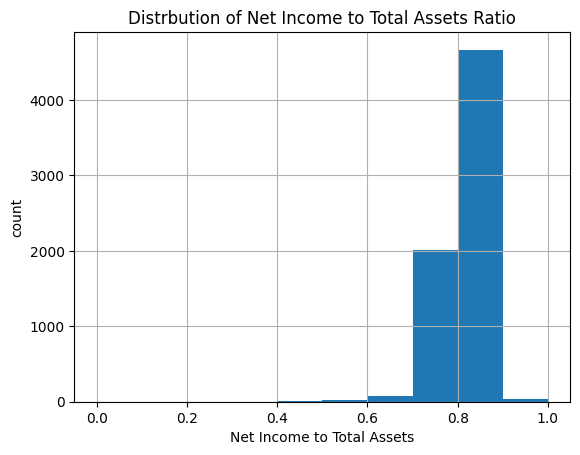

In [ ]:
df[" Net Income to Total Assets"].hist()
plt.xlabel("Net Income to Total Assets")
plt.ylabel("count")
plt.title("Distrbution of Net Income to Total Assets Ratio")

<ipython-input-63-12ff89705a20>:3: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




Text(0.5, 1.0, 'Distribution of Net Income to Total Assets Ratio, by Bankruptcy Status')

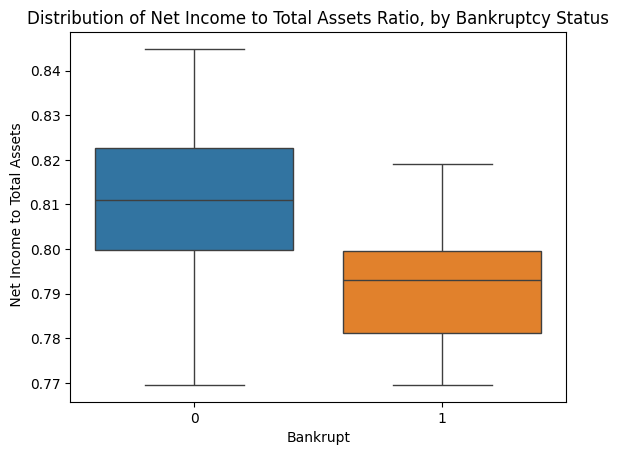

In [ ]:
q1 , q9 = df[' Net Income to Total Assets'].quantile([0.1,0.9])
mask = df[" Net Income to Total Assets"].between(q1 , q9)
sns.boxplot(x='Bankrupt?' , y=' Net Income to Total Assets', data= df[mask], palette=["#1f77b4", "#ff7f0e"])
plt.xlabel("Bankrupt")
plt.ylabel(" Net Income to Total Assets")
plt.title("Distribution of Net Income to Total Assets Ratio, by Bankruptcy Status")

<Axes: >

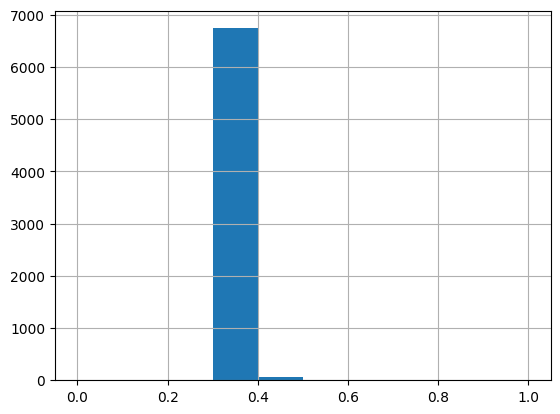

In [ ]:
df[' Borrowing dependency'].hist()

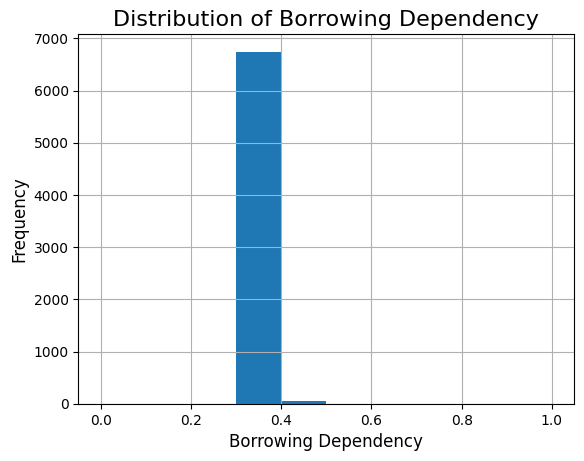

In [ ]:
df[' Borrowing dependency'].hist()
plt.title('Distribution of Borrowing Dependency', fontsize=16)

# x축과 y축 레이블 추가 (선택 사항)
plt.xlabel('Borrowing Dependency', fontsize=12)
plt.ylabel('Frequency', fontsize=12)

# 그래프 표시
plt.show()

<Axes: title={'center': ' Borrowing dependency'}, xlabel='Bankrupt?'>

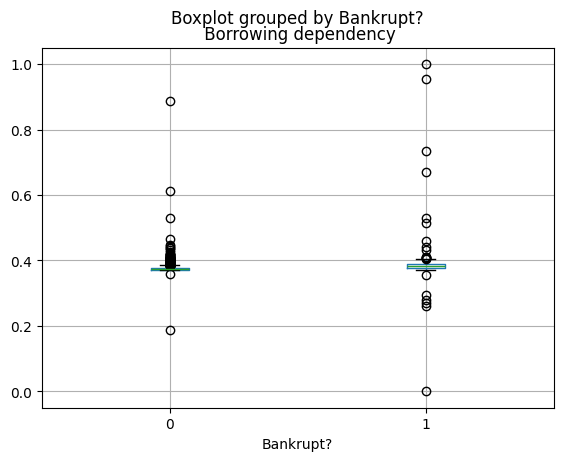

In [ ]:
df.boxplot(column=' Borrowing dependency', by='Bankrupt?')

In [ ]:
print(df[' Borrowing dependency'].describe())

count    6819.000000
mean        0.374654
std         0.016286
min         0.000000
25%         0.370168
50%         0.372624
75%         0.376271
max         1.000000
Name:  Borrowing dependency, dtype: float64


In [ ]:
high_dependency = df[df[' Borrowing dependency'] > 0.4]
print(len(high_dependency) / len(df))

0.010265434814488928


<Axes: >

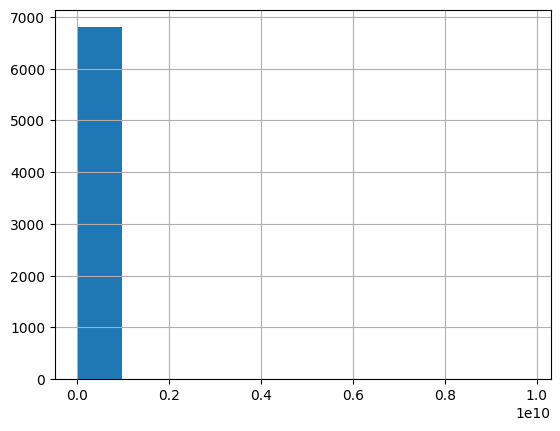

In [ ]:
df[' Total assets to GNP price'].hist()

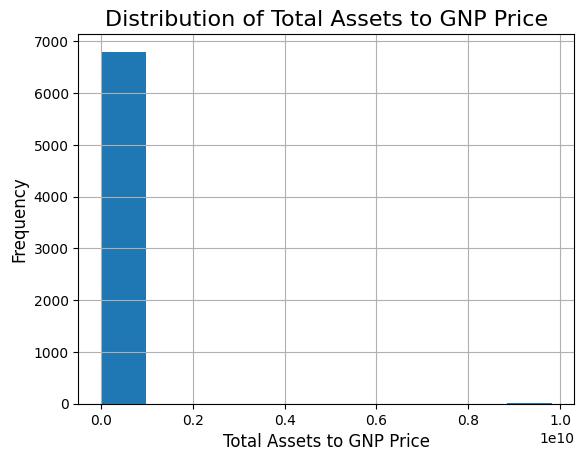

In [ ]:
df[' Total assets to GNP price'].hist()

# 제목 및 축 레이블 추가
plt.title('Distribution of Total Assets to GNP Price', fontsize=16)
plt.xlabel('Total Assets to GNP Price', fontsize=12)
plt.ylabel('Frequency', fontsize=12)

# 그래프 표시
plt.show()

<Axes: title={'center': ' Total assets to GNP price'}, xlabel='Bankrupt?'>

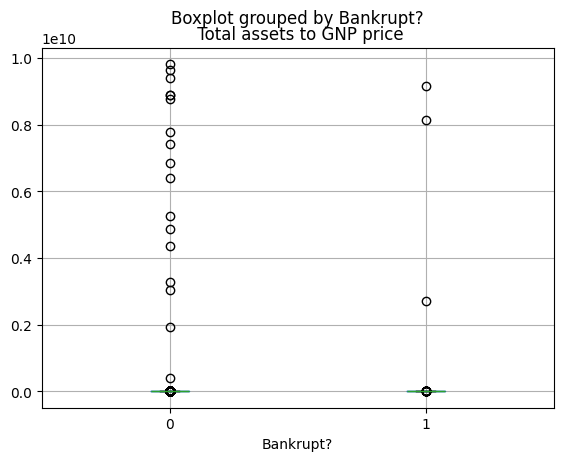

In [ ]:
df.boxplot(column=' Total assets to GNP price', by='Bankrupt?')


In [ ]:
print(df[' Total assets to GNP price'].describe())


count    6.819000e+03
mean     1.862942e+07
std      3.764501e+08
min      0.000000e+00
25%      9.036205e-04
50%      2.085213e-03
75%      5.269777e-03
max      9.820000e+09
Name:  Total assets to GNP price, dtype: float64


In [ ]:
df[[' Total assets to GNP price', 'Bankrupt?']].corr()


,Total assets to GNP price,Bankrupt?
Total assets to GNP price,1.000000,0.035104
Bankrupt?,0.035104,1.000000


Multicollinearity

<Axes: >

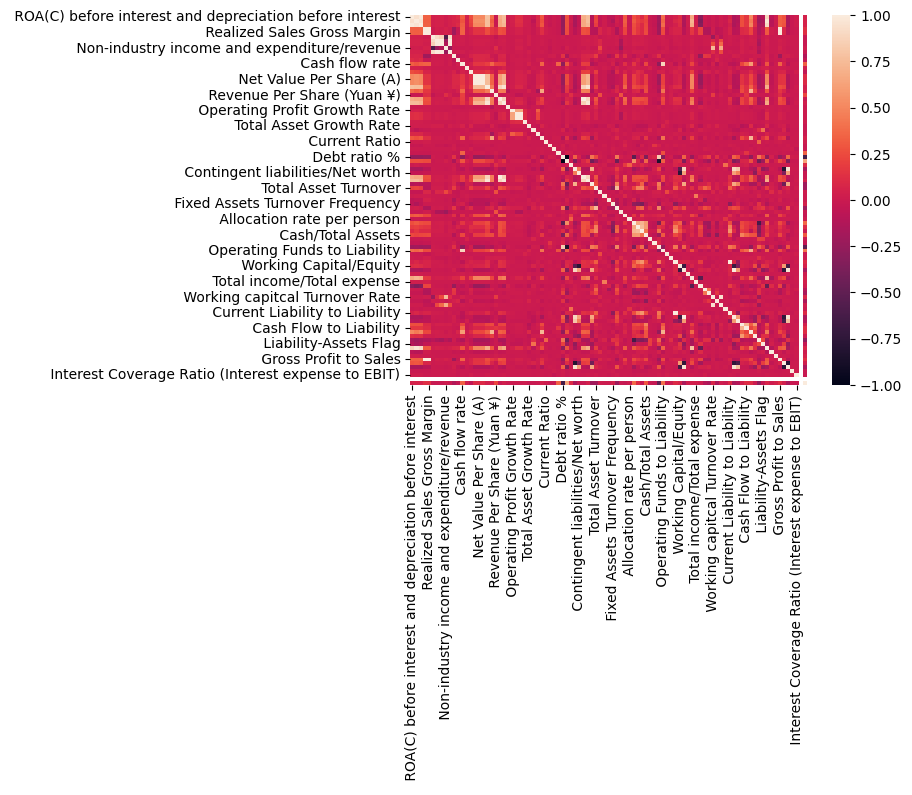

In [ ]:
corr = df.drop(columns=['Bankrupt?']).corr()
sns.heatmap(corr)

In [ ]:
#@title 상관관계가 높은 변수 추출
high_corr = corr[(corr > 0.8) & (corr < 1.0)]
print(high_corr)


                                                    ROA(C) before interest and depreciation before interest  \
ROA(C) before interest and depreciation before ...                                                NaN         
ROA(A) before interest and % after tax                                                       0.940124         
ROA(B) before interest and depreciation after tax                                            0.986849         
Operating Gross Margin                                                                            NaN         
Realized Sales Gross Margin                                                                       NaN         
...                                                                                               ...         
Liability to Equity                                                                               NaN         
Degree of Financial Leverage (DFL)                                                                NaN         
I

In [ ]:
corr_with_target = df.corr()['Bankrupt?'].sort_values(ascending=False)
print(corr_with_target)


Bankrupt?                                                   1.000000
 Debt ratio %                                               0.250161
 Current Liability to Assets                                0.194494
 Borrowing dependency                                       0.176543
 Current Liability to Current Assets                        0.171306
                                                              ...   
 ROA(C) before interest and depreciation before interest   -0.260807
 ROA(B) before interest and depreciation after tax         -0.273051
 ROA(A) before interest and % after tax                    -0.282941
 Net Income to Total Assets                                -0.315457
 Net Income Flag                                                 NaN
Name: Bankrupt?, Length: 96, dtype: float64


In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

# x_train을 DataFrame으로 변환 (필요시)
x_train = pd.DataFrame(x_train)

# VIF 계산
vif_data = pd.DataFrame()
vif_data["feature"] = x_train.columns
vif_data["VIF"] = [variance_inflation_factor(x_train.values, i) for i in range(x_train.shape[1])]

# 결과 출력
print(vif_data)



/usr/local/lib/python3.10/dist-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning:

divide by zero encountered in scalar divide



    feature         VIF
0         0  152.650575
1         1   96.475445
2         2  216.417025
3         3  705.849298
4         4  622.593507
..      ...         ...
90       90         inf
91       91    6.823627
92       92    9.686030
93       93         NaN
94       94         inf

[95 rows x 2 columns]


/usr/local/lib/python3.10/dist-packages/statsmodels/regression/linear_model.py:1784: RuntimeWarning:

invalid value encountered in scalar divide



Split

In [ ]:
target = "Bankrupt?"
X = df.drop(columns=[target])
y = df[target]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (6819, 95)
y shape: (6819,)


In [ ]:
X_train , X_test , y_train , y_test = train_test_split(X , y , test_size=0.2 , random_state=42)
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (5455, 95)
y_train shape: (5455,)
X_test shape: (1364, 95)
y_test shape: (1364,)


Resample

In [ ]:
over_sampler = RandomOverSampler(random_state=42)
X_train_over , y_train_over = over_sampler.fit_resample(X_train , y_train)
print(X_train_over.shape)
X_train_over.head()

(10572, 95)


/usr/local/lib/python3.10/dist-packages/sklearn/base.py:484: FutureWarning:

`BaseEstimator._check_n_features` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_n_features` instead.

/usr/local/lib/python3.10/dist-packages/sklearn/base.py:493: FutureWarning:

`BaseEstimator._check_feature_names` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_feature_names` instead.



,ROA(C) before interest and depreciation before interest,ROA(A) before interest and % after tax,ROA(B) before interest and depreciation after tax,Operating Gross Margin,Realized Sales Gross Margin,Operating Profit Rate,Pre-tax net Interest Rate,After-tax net Interest Rate,Non-industry income and expenditure/revenue,Continuous interest rate (after tax),...,Net Income to Total Assets,Total assets to GNP price,No-credit Interval,Gross Profit to Sales,Net Income to Stockholder's Equity,Liability to Equity,Degree of Financial Leverage (DFL),Interest Coverage Ratio (Interest expense to EBIT),Net Income Flag,Equity to Liability
0,0.498513,0.542848,0.544622,0.599194,0.599036,0.998986,0.797412,0.809330,0.303528,0.781593,...,0.801313,0.005821,0.623649,0.599196,0.840580,0.282564,0.027239,0.566658,1,0.022512
1,0.506606,0.562309,0.558863,0.609334,0.609334,0.999027,0.797450,0.809375,0.303508,0.781637,...,0.810914,0.000481,0.623932,0.609332,0.841339,0.280570,0.026843,0.565395,1,0.026670
2,0.508799,0.561001,0.554687,0.614242,0.614055,0.999094,0.797533,0.809424,0.303514,0.781692,...,0.809740,0.001397,0.623714,0.614241,0.840969,0.277772,0.026864,0.565484,1,0.041556
3,0.499976,0.562527,0.546764,0.597825,0.597825,0.999004,0.797411,0.809329,0.303490,0.781590,...,0.810082,0.000998,0.623986,0.597824,0.841885,0.286871,0.026951,0.565820,1,0.018173
4,0.477892,0.547700,0.529150,0.600362,0.600362,0.998975,0.797412,0.809333,0.303551,0.781584,...,0.804638,0.002826,0.623845,0.600363,0.840885,0.282073,0.026959,0.565848,1,0.023328


Build BaseLine

In [ ]:
acc_baseline = y_train.value_counts(normalize=True).max()
print("Baseline Accuracy:", round(acc_baseline, 4))

Baseline Accuracy: 0.969


Iterate

In [ ]:
clf = RandomForestClassifier(random_state=42)

In [ ]:
params= {

    "n_estimators":range(25 , 100 , 25),
    "max_depth": range(10 , 70 , 10)

}
params

{'n_estimators': range(25, 100, 25), 'max_depth': range(10, 70, 10)}

In [ ]:
model = GridSearchCV(

    clf,
    param_grid= params,
    cv=5,
    n_jobs=-1,
    verbose= 1

)
model

GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': range(10, 70, 10),
                         'n_estimators': range(25, 100, 25)},
             verbose=1)

In [ ]:
model.fit(X_train_over , y_train_over)

Fitting 5 folds for each of 18 candidates, totalling 90 fits


GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': range(10, 70, 10),
                         'n_estimators': range(25, 100, 25)},
             verbose=1)

In [ ]:
cv_results = pd.DataFrame(model.cv_results_)
#print(cv_results.columns)
cv_results.sort_values('rank_test_score').head(10)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_max_depth,param_n_estimators,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
13,3.171077,0.025661,0.029932,0.001927,50,50,"{'max_depth': 50, 'n_estimators': 50}",0.991962,0.995272,0.995743,0.995743,0.995270,0.994798,0.001433,1
16,4.351654,1.067385,0.043399,0.018581,60,50,"{'max_depth': 60, 'n_estimators': 50}",0.991962,0.995272,0.995743,0.995743,0.995270,0.994798,0.001433,1
10,3.821000,0.908599,0.048807,0.016894,40,50,"{'max_depth': 40, 'n_estimators': 50}",0.991489,0.995272,0.994797,0.995743,0.994797,0.994419,0.001506,3
15,1.722259,0.103406,0.023685,0.008460,60,25,"{'max_depth': 60, 'n_estimators': 25}",0.991017,0.995272,0.995743,0.994797,0.994324,0.994230,0.001675,4
12,2.755406,0.278808,0.033051,0.013899,50,25,"{'max_depth': 50, 'n_estimators': 25}",0.991017,0.995272,0.995743,0.994797,0.994324,0.994230,0.001675,4
17,5.782333,1.036471,0.049685,0.018793,60,75,"{'max_depth': 60, 'n_estimators': 75}",0.991017,0.994799,0.994324,0.996216,0.994324,0.994136,0.001707,6
14,5.890617,1.203806,0.049066,0.018091,50,75,"{'max_depth': 50, 'n_estimators': 75}",0.991017,0.994799,0.994324,0.996216,0.994324,0.994136,0.001707,6
11,5.402009,0.988354,0.055906,0.022635,40,75,"{'max_depth': 40, 'n_estimators': 75}",0.991489,0.994799,0.994324,0.995743,0.994324,0.994136,0.001421,8
9,1.824395,0.317087,0.019469,0.000663,40,25,"{'max_depth': 40, 'n_estimators': 25}",0.991017,0.994799,0.995270,0.994324,0.994797,0.994041,0.001542,9
8,5.683974,1.252519,0.056023,0.017559,30,75,"{'max_depth': 30, 'n_estimators': 75}",0.990071,0.993381,0.993377,0.994324,0.991485,0.992528,0.001536,10


In [ ]:
model.best_params_

{'max_depth': 50, 'n_estimators': 50}

In [ ]:
model.predict(X_train_over)

array([0, 0, 0, ..., 1, 1, 1])

Evaluate

In [ ]:
acc_train = model.score(X_train_over , y_train_over)
acc_test = model.score(X_test , y_test)

print(f"Training accuracy: {round(acc_train , 4)}")
print(f"test accuracy: {round(acc_test , 4)}")

Training accuracy: 1.0
test accuracy: 0.967


Make a confusion matrix to see how our model is making its correct and incorrect predictions.

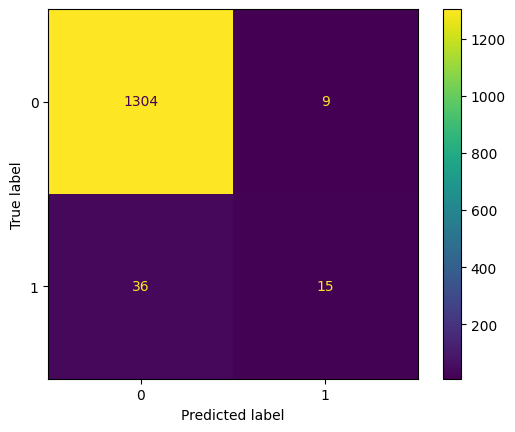

In [ ]:
ConfusionMatrixDisplay.from_estimator(

    model,
    X_test,
    y_test

)

Make a Classification report to look at the whole picture of the classification model performances. A classification report includes precision, recall, F1 score and support.

In [ ]:
print(classification_report(

    y_test,
    model.predict(X_test)

))

              precision    recall  f1-score   support

           0       0.97      0.99      0.98      1313
           1       0.62      0.29      0.40        51

    accuracy                           0.97      1364
   macro avg       0.80      0.64      0.69      1364
weighted avg       0.96      0.97      0.96      1364



Communication

In [ ]:
features = X_test.columns
importances = model.best_estimator_.feature_importances_

Text(0.5, 1.0, 'Feature Importance')

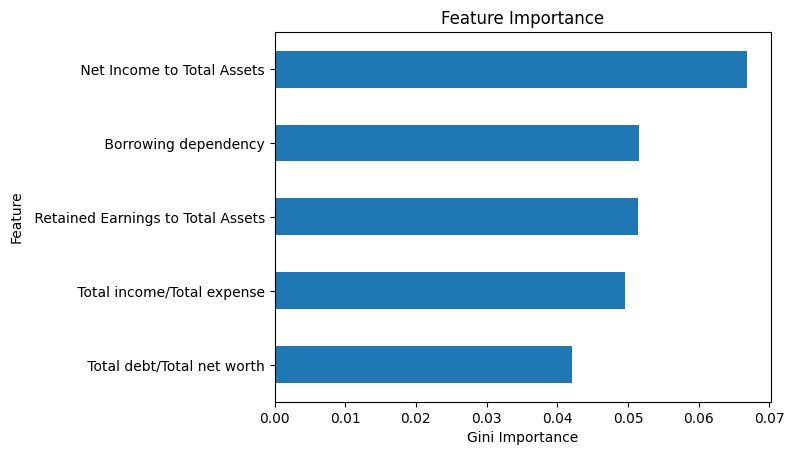

In [ ]:
feat_imp = pd.Series(importances , index=features).sort_values()
feat_imp.tail().plot(kind= 'barh')
plt.xlabel("Gini Importance")
plt.ylabel("Feature")
plt.title("Feature Importance")

In [ ]:
with open("model-1" , "wb") as f:
    pickle.dump(model ,f)

97acc

In [ ]:
#@title Feature Selection

from sklearn.model_selection import train_test_split

# to obtain the mutual information values
from sklearn.feature_selection import mutual_info_classif
# to select the features
from sklearn.feature_selection import SelectKBest

In [ ]:
# separate train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    bkdata.drop(labels=['Bankrupt?'], axis=1),
    bkdata['Bankrupt?'],
    test_size=0.3,
    random_state=0)

X_train.shape, X_test.shape

((4773, 95), (2046, 95))

In [ ]:
#@title Determine Mutual Information
# calculate the mutual information between the variables and the target

# the smaller the value of the mi, the less information we can infer from
# the feature about the target

mi = mutual_info_classif(X_train, y_train)
mi

array([0.02831263, 0.03415383, 0.0297934 , 0.01659699, 0.01786529,
       0.02045657, 0.03039124, 0.02839945, 0.03086962, 0.03651483,
       0.        , 0.        , 0.01367531, 0.        , 0.01919374,
       0.03093909, 0.03155871, 0.02714468, 0.043217  , 0.00601642,
       0.00567616, 0.02255866, 0.0439023 , 0.0091431 , 0.00635823,
       0.01232528, 0.00976722, 0.01118946, 0.01263331, 0.        ,
       0.01208822, 0.00143543, 0.01277356, 0.        , 0.03433605,
       0.00897657, 0.03437751, 0.03528038, 0.01050352, 0.04017154,
       0.00418023, 0.02429237, 0.04275133, 0.00503737, 0.0131228 ,
       0.        , 0.        , 0.        , 0.00504897, 0.        ,
       0.        , 0.02435957, 0.00284438, 0.02650192, 0.00576042,
       0.00071265, 0.01679241, 0.00060894, 0.00350824, 0.01610328,
       0.01731491, 0.02261026, 0.00455264, 0.0029954 , 0.02232087,
       0.02399633, 0.0027366 , 0.03457833, 0.03417276, 0.00907948,
       0.00022808, 0.00391116, 0.01903018, 0.00135965, 0.00380

Text(0, 0.5, 'Mutual Information')

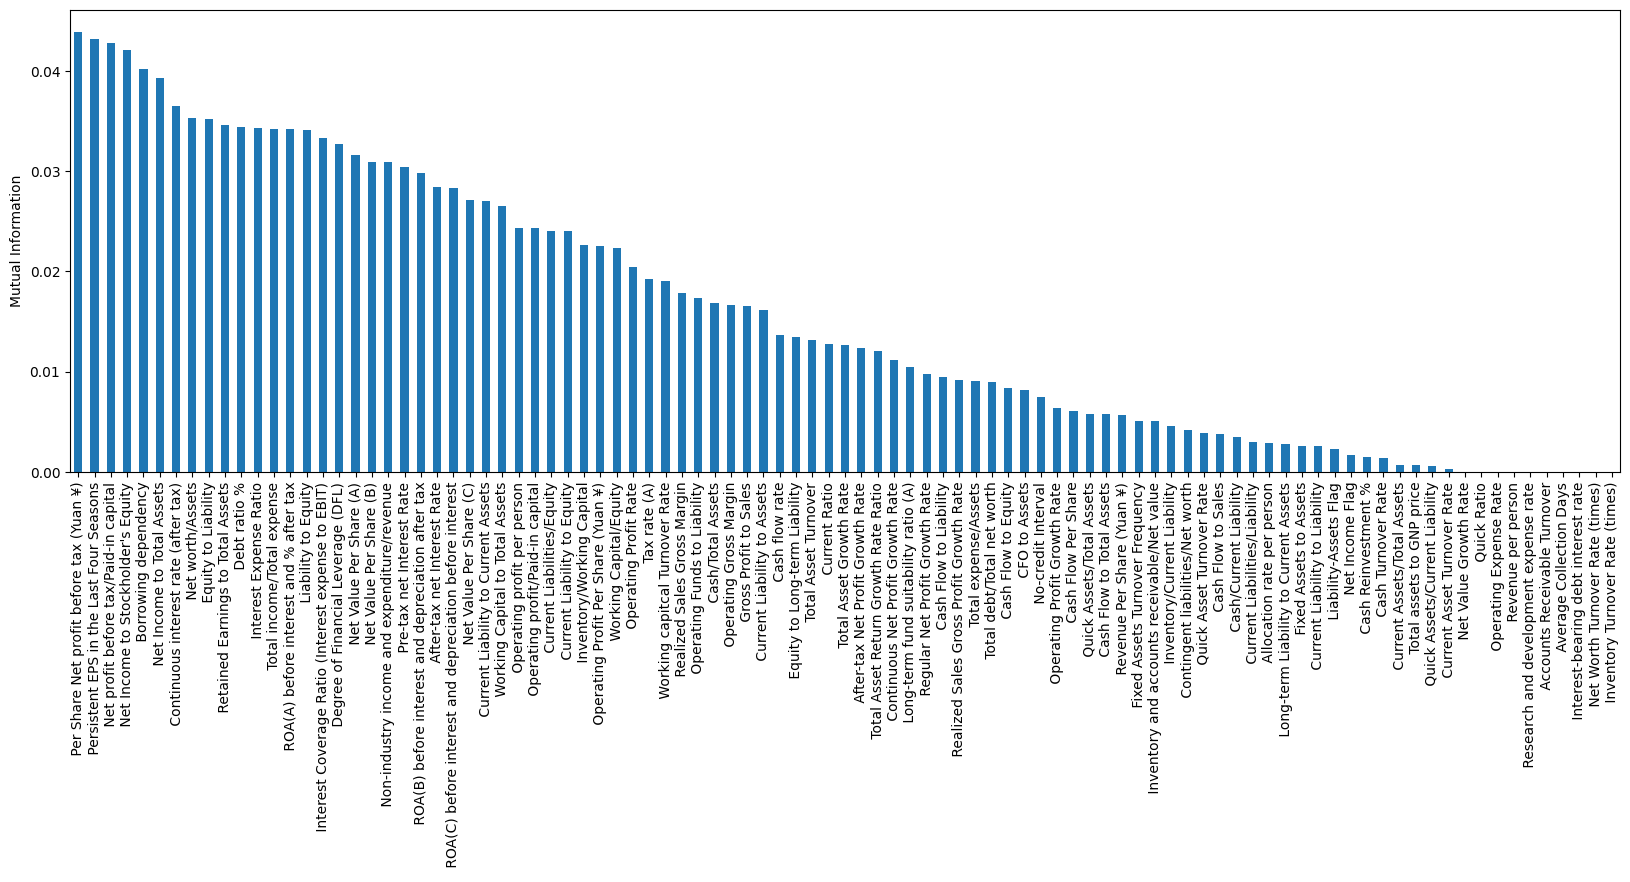

In [ ]:
# 1) let's capture the above array in a pandas series
# 2)add the variable names in the index
# 3) sort the features based on their mutual information value
# 4) and make a var plot

mi = pd.Series(mi)
mi.index = X_train.columns
mi.sort_values(ascending=False).plot.bar(figsize=(20, 6))
plt.ylabel('Mutual Information')

There are a few features (left of the plot) with higher mutual information values. There are also features with almost zero MI values on the right of the plot.

Once we find the mutual information values, to select features we need to determine a threshold, or cut-off value, above which a feature will be selected.

There are a few ways in which this can be done:

Select top k features, where k is an arbitrary number of features

In [ ]:
#@title Select top k features based on MI
# here we will select the top 10 features
# based on their mutual information value

# select features
sel_ = SelectKBest(mutual_info_classif, k=10).fit(X_train, y_train)

# display features
X_train.columns[sel_.get_support()]

Index([' Continuous interest rate (after tax)',
       ' Persistent EPS in the Last Four Seasons',
       ' Per Share Net profit before tax (Yuan ¥)', ' Debt ratio %',
       ' Net worth/Assets', ' Borrowing dependency',
       ' Net profit before tax/Paid-in capital', ' Net Income to Total Assets',
       ' Net Income to Stockholder's Equity', ' Equity to Liability'],
      dtype='object')

In [ ]:
# to remove the rest of the features:

X_train = sel_.transform(X_train)
X_test = sel_.transform(X_test)

In [ ]:
X_train.shape,X_test.shape

((4773, 10), (2046, 10))

In [ ]:
#@title Feature Scaling
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [ ]:
#@title Logistic Regression
from sklearn.linear_model import LogisticRegression
classifier = LogisticRegression(random_state = 0)
classifier.fit(X_train, y_train)

LogisticRegression(random_state=0)

In [ ]:
y_pred = classifier.predict(X_test)
print(y_pred)

[0 0 0 ... 0 0 0]


In [ ]:
from sklearn.metrics import accuracy_score
acc1 = accuracy_score(y_test, y_pred)
print(f"Accuracy score: {acc1}")

Accuracy score: 0.9696969696969697


In [ ]:
#@title SVM
from sklearn.svm import SVC
classifier = SVC(kernel = 'linear', random_state = 0)
classifier.fit(X_train, y_train)

SVC(kernel='linear', random_state=0)

In [ ]:
#@title Predict the test set result of SVM
y_pred = classifier.predict(X_test)
from sklearn.metrics import confusion_matrix, accuracy_score
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[1987    0]
 [  58    1]]


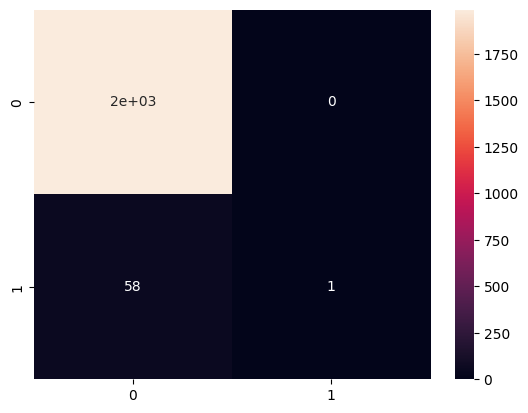

In [ ]:
sns.heatmap(cm,annot=True)
plt.show()

In [ ]:
acc2 = accuracy_score(y_test, y_pred)
print(f"Accuracy score: {acc2}")

Accuracy score: 0.9716520039100685


In [ ]:
#@title Training the KNN model on the Training set
from sklearn.neighbors import KNeighborsClassifier
classifier = KNeighborsClassifier(n_neighbors = 5, metric = 'minkowski', p = 2)
classifier.fit(X_train, y_train)

KNeighborsClassifier()

In [ ]:
y_pred = classifier.predict(X_test)

In [ ]:
#@title KNN confusion matrix
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[1961   26]
 [  45   14]]


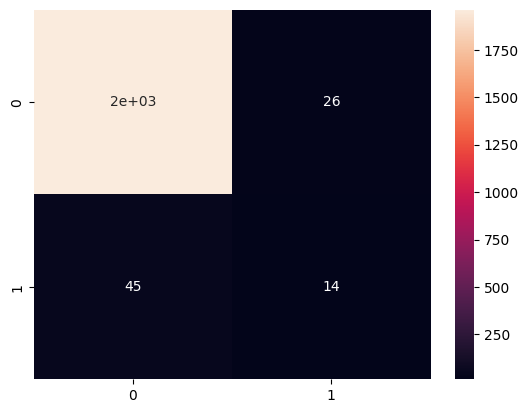

In [ ]:
sns.heatmap(cm,annot=True)
plt.show()

In [ ]:
acc3 = accuracy_score(y_test, y_pred)
print(f"Accuracy score: {acc3}")

Accuracy score: 0.9652981427174976


In [ ]:
#@title Training the Naive Bayes on the Training set
from sklearn.naive_bayes import GaussianNB
classifier = GaussianNB()
classifier.fit(X_train, y_train)

GaussianNB()

In [ ]:
y_pred = classifier.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[1923   64]
 [  27   32]]


In [ ]:
acc4 = accuracy_score(y_test, y_pred)
print(f"Accuracy score : {acc4}")

Accuracy score : 0.955522971652004


In [ ]:
#@title Training Decision Tree Classification on Train set
from sklearn.tree import DecisionTreeClassifier
classifier = DecisionTreeClassifier(criterion = 'entropy', random_state = 0)
classifier.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', random_state=0)

In [ ]:
y_pred = classifier.predict(X_test)
acc5 = accuracy_score(y_test, y_pred)
print(f"Accuracy score: {acc5}")

Accuracy score: 0.947702834799609


In [ ]:
#@title Training the Random Forest Classification model on the Training set
from sklearn.ensemble import RandomForestClassifier
classifier = RandomForestClassifier(n_estimators = 10, criterion = 'entropy', random_state = 0)
classifier.fit(X_train, y_train)

RandomForestClassifier(criterion='entropy', n_estimators=10, random_state=0)

In [ ]:
y_pred = classifier.predict(X_test)
from sklearn.metrics import confusion_matrix, accuracy_score
cm = confusion_matrix(y_test, y_pred)
print(cm)
acc6 = accuracy_score(y_test, y_pred)

[[1973   14]
 [  50    9]]


In [ ]:
print(f"Random Forest Classification accuracy: {acc6}")

Random Forest Classification accuracy: 0.9687194525904204


In [ ]:
#@title XG Boost
from xgboost import XGBClassifier
classifier = XGBClassifier()
classifier.fit(X_train, y_train)

/usr/local/lib/python3.10/dist-packages/sklearn/utils/_tags.py:354: FutureWarning:

The XGBClassifier or classes from which it inherits use `_get_tags` and `_more_tags`. Please define the `__sklearn_tags__` method, or inherit from `sklearn.base.BaseEstimator` and/or other appropriate mixins such as `sklearn.base.TransformerMixin`, `sklearn.base.ClassifierMixin`, `sklearn.base.RegressorMixin`, and `sklearn.base.OutlierMixin`. From scikit-learn 1.7, not defining `__sklearn_tags__` will raise an error.



AttributeError: 'super' object has no attribute '__sklearn_tags__'

AttributeError: 'super' object has no attribute '__sklearn_tags__'

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, random_state=None, ...)

In [ ]:
#@title XG Boost Classifier confusin matrix
y_pred = classifier.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
print(cm)
acc7 = accuracy_score(y_test, y_pred)

[[1966   21]
 [  47   12]]


In [ ]:
print(f"By XG Boost classifier Acc: {acc7}")

By XG Boost classifier Acc: 0.9667644183773216


In [ ]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.7/98.7 MB 7.8 MB/s eta 0:00:00


In [ ]:
#@title Training CatBoost on the training set
from catboost import CatBoostClassifier
classifier = CatBoostClassifier()
classifier.fit(X_train, y_train)

Learning rate set to 0.020081
0:	learn: 0.6496940	total: 80.3ms	remaining: 1m 20s
1:	learn: 0.6044917	total: 100ms	remaining: 50.1s
2:	learn: 0.5622949	total: 134ms	remaining: 44.4s
3:	learn: 0.5240697	total: 180ms	remaining: 44.7s
4:	learn: 0.4912042	total: 215ms	remaining: 42.8s
5:	learn: 0.4607658	total: 248ms	remaining: 41s
6:	learn: 0.4335303	total: 293ms	remaining: 41.5s
7:	learn: 0.4062611	total: 334ms	remaining: 41.4s
8:	learn: 0.3815863	total: 373ms	remaining: 41.1s
9:	learn: 0.3606635	total: 395ms	remaining: 39.1s
10:	learn: 0.3419757	total: 428ms	remaining: 38.5s
11:	learn: 0.3232164	total: 452ms	remaining: 37.2s
12:	learn: 0.3048934	total: 508ms	remaining: 38.6s
13:	learn: 0.2899081	total: 538ms	remaining: 37.9s
14:	learn: 0.2752334	total: 599ms	remaining: 39.4s
15:	learn: 0.2622553	total: 631ms	remaining: 38.8s
16:	learn: 0.2507765	total: 654ms	remaining: 37.8s
17:	learn: 0.2385888	total: 693ms	remaining: 37.8s
18:	learn: 0.2290213	total: 724ms	remaining: 37.4s
19:	learn: 

In [ ]:
y_pred = classifier.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
print(cm)
acc8 = accuracy_score(y_test, y_pred)

[[1974   13]
 [  50    9]]


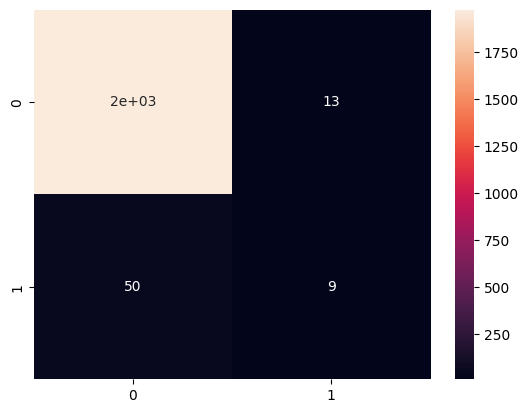

In [ ]:
sns.heatmap(cm,annot=True)
plt.show()

In [ ]:
print(acc8)

0.969208211143695


Create visualization of all models

<ipython-input-141-253c2ebc3a37>:21: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




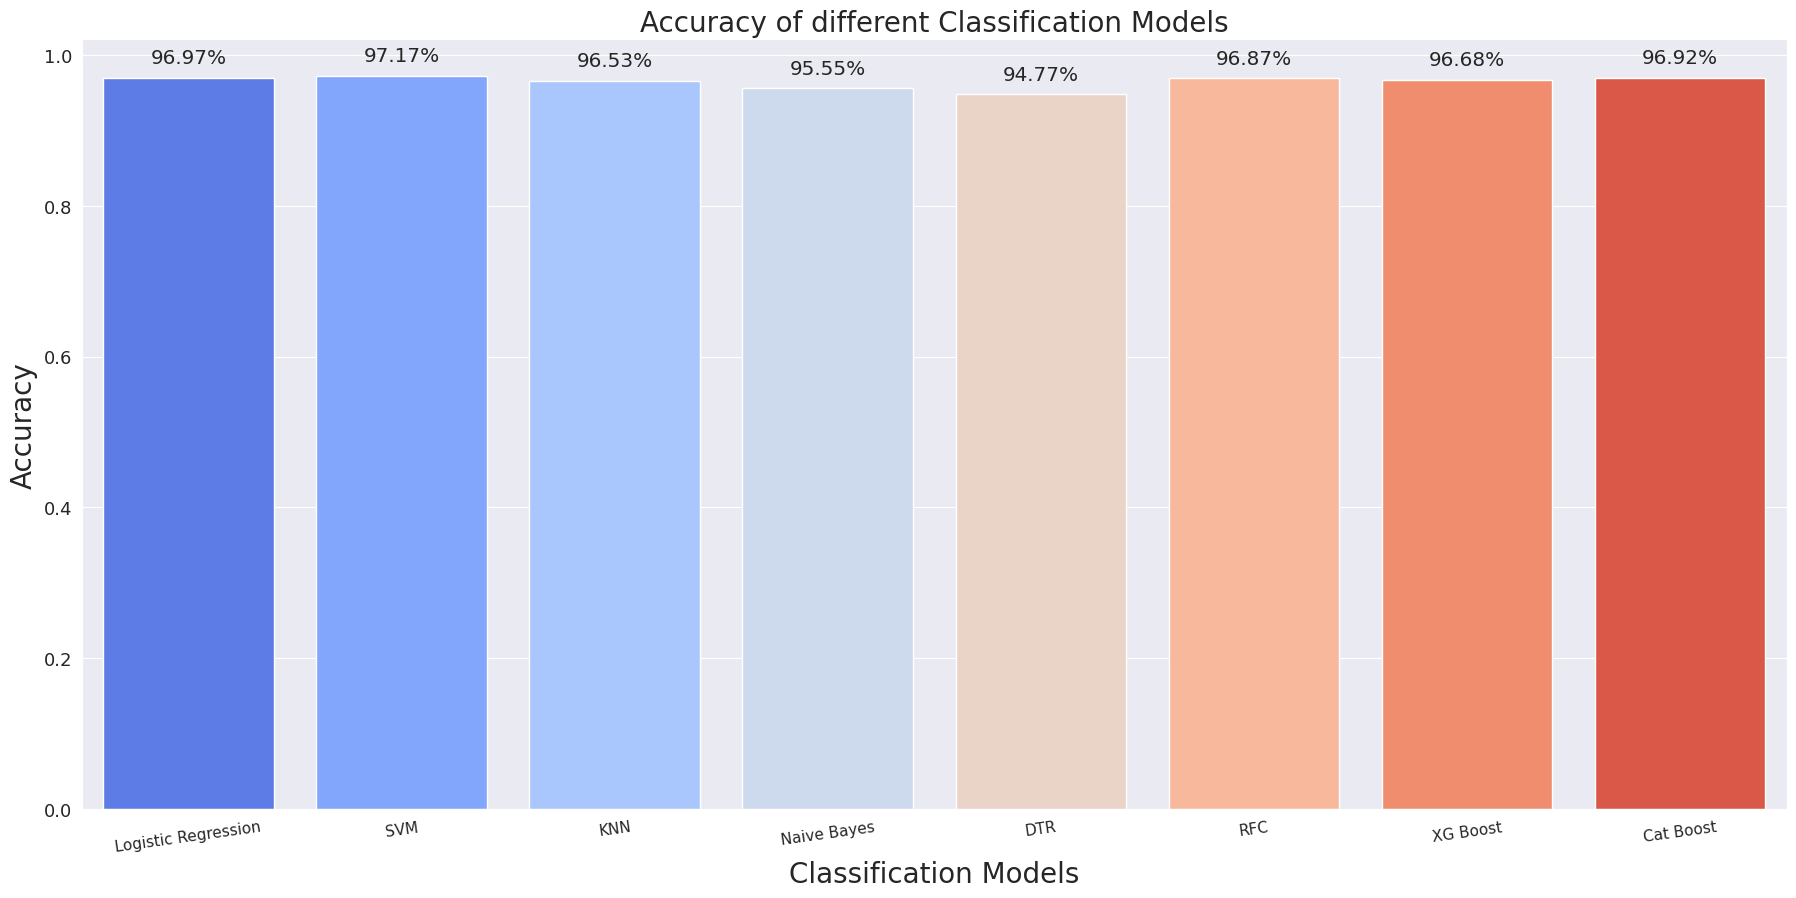

In [ ]:
mylist=[]
mylist2=[]
mylist.append(acc1)
mylist2.append("Logistic Regression")
mylist.append(acc2)
mylist2.append("SVM")
mylist.append(acc3)
mylist2.append("KNN")
mylist.append(acc4)
mylist2.append("Naive Bayes")
mylist.append(acc5)
mylist2.append("DTR")
mylist.append(acc6)
mylist2.append("RFC")
mylist.append(acc7)
mylist2.append("XG Boost")
mylist.append(acc8)
mylist2.append("Cat Boost")
plt.rcParams['figure.figsize']=22,10
sns.set_style("darkgrid")
ax = sns.barplot(x=mylist2, y=mylist, palette = "coolwarm", saturation =1.5)
plt.xlabel("Classification Models", fontsize = 20 )
plt.ylabel("Accuracy", fontsize = 20)
plt.title("Accuracy of different Classification Models", fontsize = 20)
plt.xticks(fontsize = 11, horizontalalignment = 'center', rotation = 8)
plt.yticks(fontsize = 13)
for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    x, y = p.get_xy()
    ax.annotate(f'{height:.2%}', (x + width/2, y + height*1.02), ha='center', fontsize = 'x-large')
plt.show()

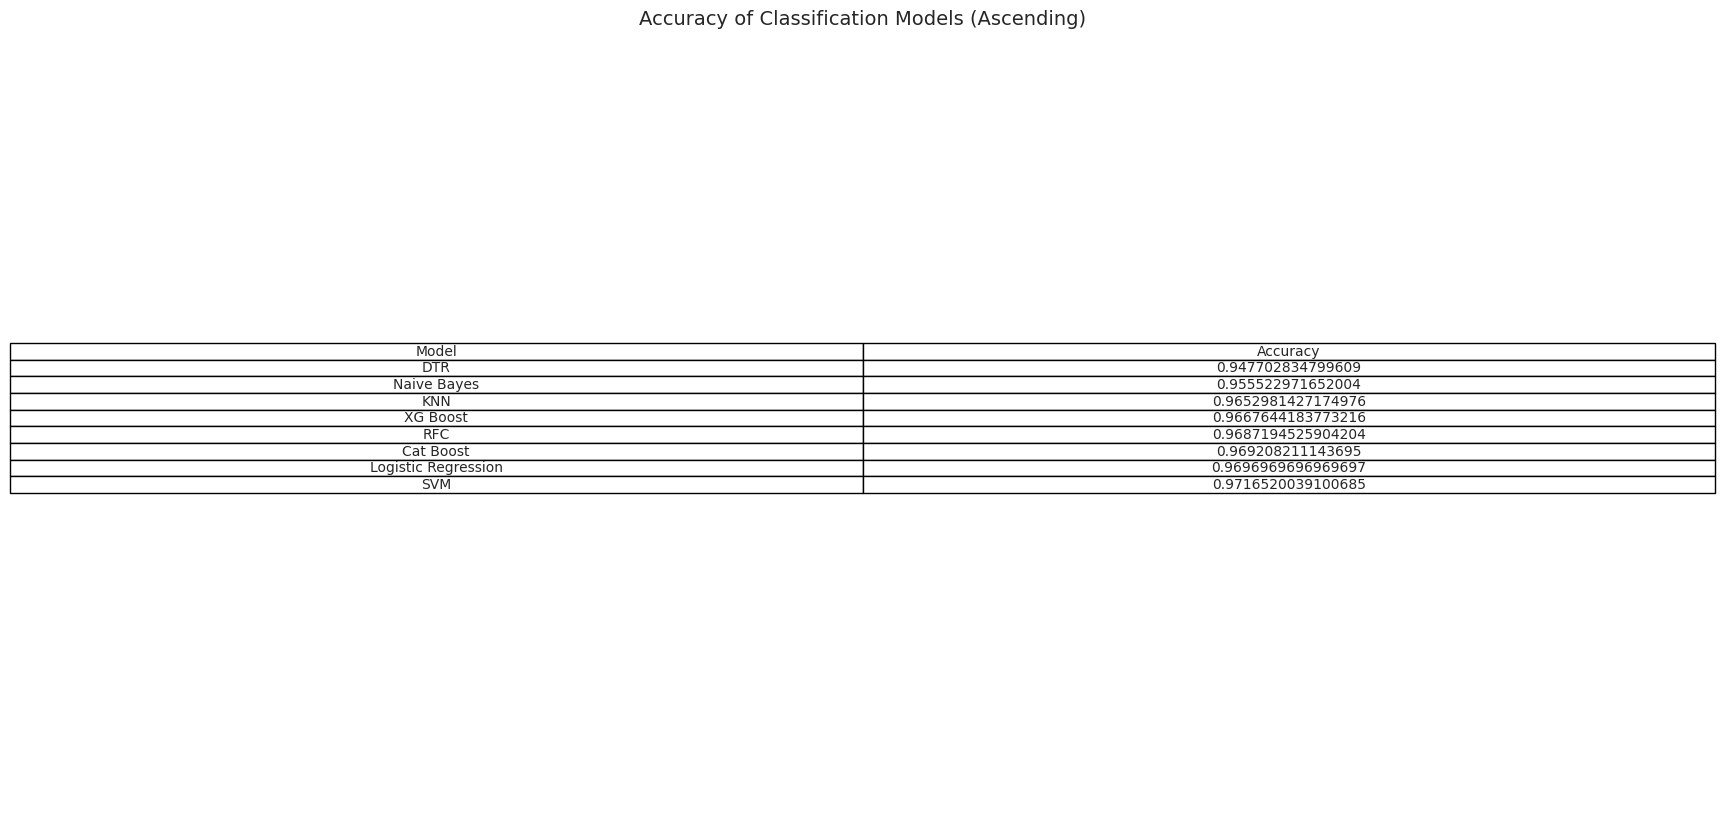

In [ ]:
import pandas as pd

# Create a DataFrame from the lists
data = pd.DataFrame({
    "Model": mylist2,
    "Accuracy": mylist
})

# Sort the DataFrame by Accuracy in ascending order
sorted_data = data.sort_values(by="Accuracy")

# Display the sorted table
import matplotlib.pyplot as plt
plt.axis('off')  # Turn off the plot axis
plt.table(cellText=sorted_data.values, colLabels=sorted_data.columns, cellLoc='center', loc='center')
plt.title("Accuracy of Classification Models (Ascending)", fontsize=14)
plt.show()


In [ ]:
import pandas as pd

# Create a DataFrame from the lists
data = pd.DataFrame({
    "Model": mylist2,
    "Accuracy": mylist
})


sorted_data = data.sort_values(by="Accuracy", ascending=False)
sorted_data

,Model,Accuracy
1,SVM,0.971652
0,Logistic Regression,0.969697
7,Cat Boost,0.969208
5,RFC,0.968719
6,XG Boost,0.966764
2,KNN,0.965298
3,Naive Bayes,0.955523
4,DTR,0.947703


In [ ]:
ddf = bkdata.copy()

In [ ]:
ddf.head()

,Bankrupt?,ROA(C) before interest and depreciation before interest,ROA(A) before interest and % after tax,ROA(B) before interest and depreciation after tax,Operating Gross Margin,Realized Sales Gross Margin,Operating Profit Rate,Pre-tax net Interest Rate,After-tax net Interest Rate,Non-industry income and expenditure/revenue,...,Net Income to Total Assets,Total assets to GNP price,No-credit Interval,Gross Profit to Sales,Net Income to Stockholder's Equity,Liability to Equity,Degree of Financial Leverage (DFL),Interest Coverage Ratio (Interest expense to EBIT),Net Income Flag,Equity to Liability
0,1,0.370594,0.424389,0.405750,0.601457,0.601457,0.998969,0.796887,0.808809,0.302646,...,0.716845,0.009219,0.622879,0.601453,0.827890,0.290202,0.026601,0.564050,1,0.016469
1,1,0.464291,0.538214,0.516730,0.610235,0.610235,0.998946,0.797380,0.809301,0.303556,...,0.795297,0.008323,0.623652,0.610237,0.839969,0.283846,0.264577,0.570175,1,0.020794
2,1,0.426071,0.499019,0.472295,0.601450,0.601364,0.998857,0.796403,0.808388,0.302035,...,0.774670,0.040003,0.623841,0.601449,0.836774,0.290189,0.026555,0.563706,1,0.016474
3,1,0.399844,0.451265,0.457733,0.583541,0.583541,0.998700,0.796967,0.808966,0.303350,...,0.739555,0.003252,0.622929,0.583538,0.834697,0.281721,0.026697,0.564663,1,0.023982
4,1,0.465022,0.538432,0.522298,0.598783,0.598783,0.998973,0.797366,0.809304,0.303475,...,0.795016,0.003878,0.623521,0.598782,0.839973,0.278514,0.024752,0.575617,1,0.035490


In [ ]:
X = ddf.drop(['Bankrupt?'],axis=1).values
y = ddf['Bankrupt?'].values

In [ ]:
#@title Split the data set (for PCA)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 0)
X_train.shape,X_test.shape

((5455, 95), (1364, 95))

In [ ]:
#@title Feature Scaling
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [ ]:
#@title PCA
from sklearn.decomposition import PCA
pca = PCA(n_components = 2)
X_train = pca.fit_transform(X_train)
X_test = pca.transform(X_test)

In [ ]:
X_train.shape,X_test.shape

((5455, 2), (1364, 2))

In [ ]:
from sklearn.linear_model import LogisticRegression
classifier = LogisticRegression(random_state = 0)
classifier.fit(X_train, y_train)

LogisticRegression(random_state=0)

In [ ]:
from sklearn.metrics import confusion_matrix, accuracy_score
y_pred = classifier.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
print(cm)
pca_acc = accuracy_score(y_test, y_pred)

[[1312    6]
 [  42    4]]


In [ ]:
print(f"PCA Accuracy is: {pca_acc}")

PCA Accuracy is: 0.9648093841642229


In [ ]:
#@title Applying k-Fold Cross Validation
from sklearn.model_selection import cross_val_score
accuracies = cross_val_score(estimator = classifier, X = X_train, y = y_train, cv = 10)
print("Accuracy: {:.2f} %".format(accuracies.mean()*100))
print("Standard Deviation: {:.2f} %".format(accuracies.std()*100))

Accuracy: 96.63 %
Standard Deviation: 0.37 %
